# TP N° : 03 :Histogrammes
#### Objectifs du TP
- Afficher la luminosité et le contraste d’une image.
- Calculer et afficher manuellement les histogrammes d’une image en niveau de gris et
des canaux de couleur (rouge, vert, bleu) d'une image en couleur.
- Appliquer les différentes méthodes d’amélioration de la luminosité et de contraste





**Importer les bibliothèques nécessaires**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


### 1/ Image en niveau de gris:

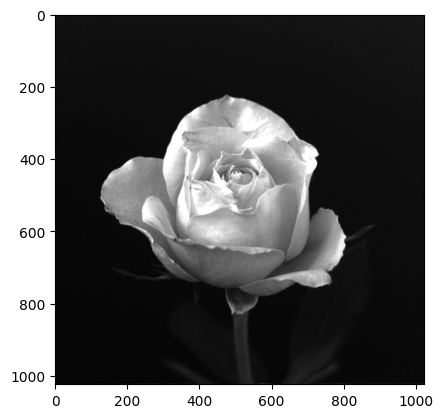

In [2]:
# Charger l'image en niveaux de gris
image = cv2.imread(r"C:\Users\mihna\OneDrive\Bureau\TR img\rose_1024.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")
plt.show()

2. Calcul de la luminosité
La formule utilisée est : 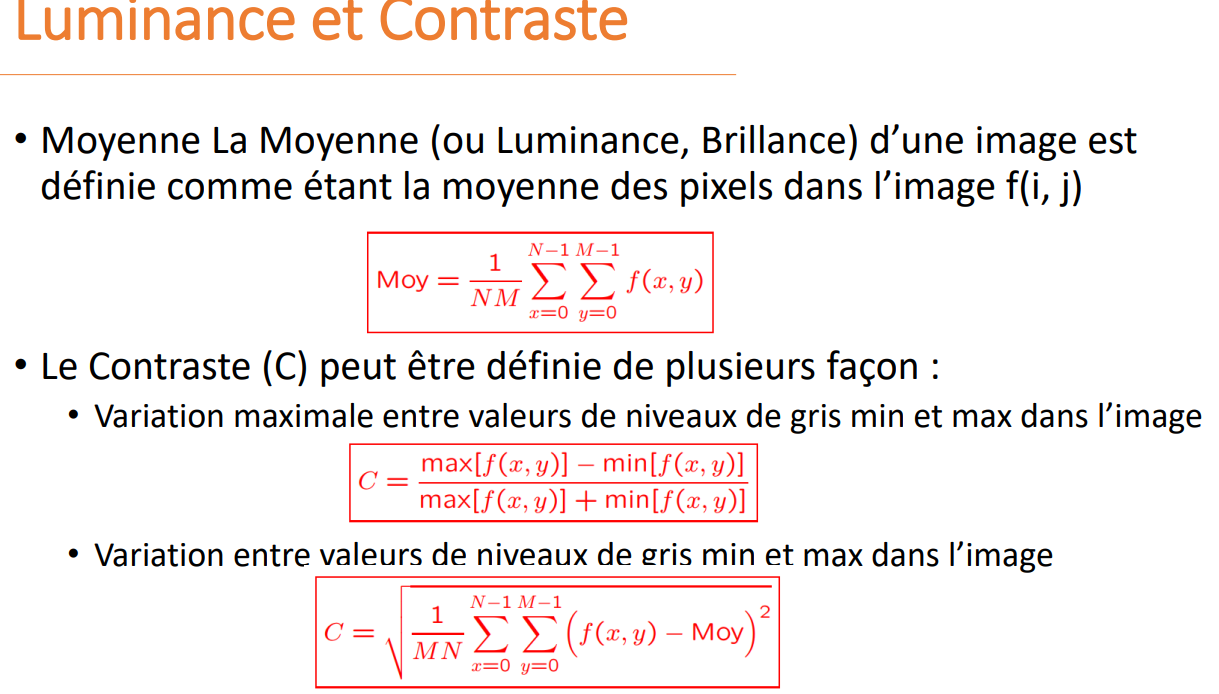

In [3]:
image.shape

(1024, 1024)

In [4]:
# Calcul de la luminance (moyenne des intensités des pixels)
total_pixels = image.shape[0] * image.shape[1]  # N : Nombre total de pixels
sum_intensities = np.sum(image)  # Somme des intensités
luminance = sum_intensities / total_pixels  # Moyenne
print(f"Luminosité calculée : {luminance}")



Luminosité calculée : 46.789353370666504


In [5]:
luminosity = np.mean(image)
print(f"Luminosité de l'image : {luminosity}")

Luminosité de l'image : 46.789353370666504


In [6]:
# Calcul de la luminosité avec OpenCV
luminance_opencv = cv2.mean(image)[0]  # cv2.mean retourne un tuple, [0] pour récupérer la moyenne
print(f"Luminosité calculée avec OpenCV : {luminance_opencv}")

Luminosité calculée avec OpenCV : 46.789353370666504


#### 2-Calcul du contraste

In [7]:
contrast = np.std(image)
print(f"Contraste de l'image : {contrast}")


Contraste de l'image : 66.10413489735092


##### 3-Calcul de l'histogramme

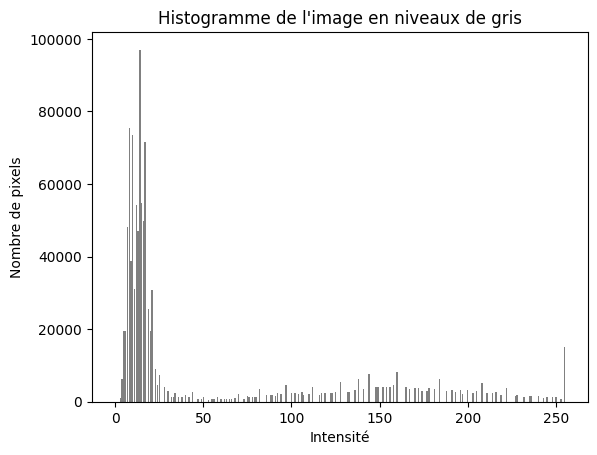

In [8]:
# Initialiser l'histogramme
histogram = np.zeros(256, dtype=int)

# Remplir l'histogramme
for pixel in image.flatten():
    histogram[pixel] += 1

# Afficher l'histogramme
plt.bar(range(256), histogram, color='gray')
plt.title("Histogramme de l'image en niveaux de gris")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.show()


### Partie 2 : Image en couleur

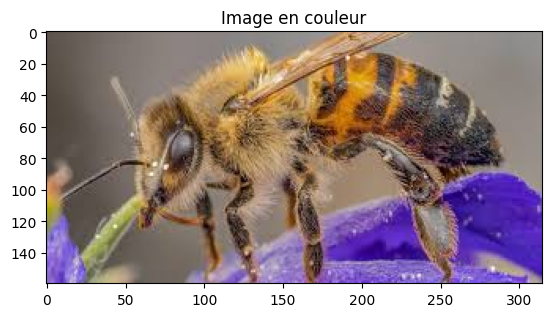

In [9]:
import cv2
import matplotlib.pyplot as plt

image_color = cv2.imread(r'C:\Users\mihna\OneDrive\Bureau\TR img\TP3 Ressources\bee1.tif')  
plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.title("Image en couleur")
plt.show()


#### 2-Séparation des canaux

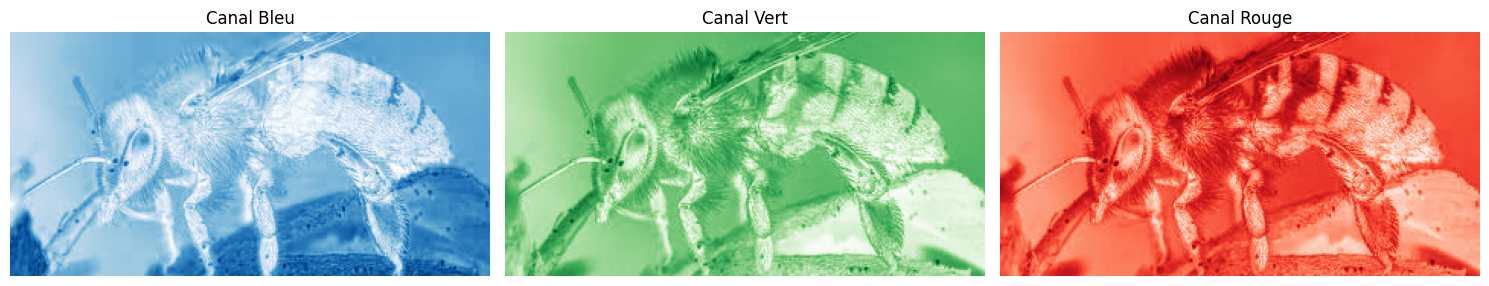

In [10]:
# 2. Séparation des canaux
blue_channel, green_channel, red_channel = cv2.split(image_color)

# Afficher les trois canaux séparés
plt.figure(figsize=(15, 5))

    # Canal bleu
plt.subplot(1, 3, 1)
plt.imshow(blue_channel, cmap='Blues')
plt.title("Canal Bleu")
plt.axis('off')

    # Canal vert
plt.subplot(1, 3, 2)
plt.imshow(green_channel, cmap='Greens')
plt.title("Canal Vert")
plt.axis('off')

    # Canal rouge
plt.subplot(1, 3, 3)
plt.imshow(red_channel, cmap='Reds')
plt.title("Canal Rouge")
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
# Initialiser les histogrammes
hist_blue = np.zeros(256, dtype=int)  # Pour les intensités 0-255
hist_green = np.zeros(256, dtype=int)
hist_red = np.zeros(256, dtype=int)


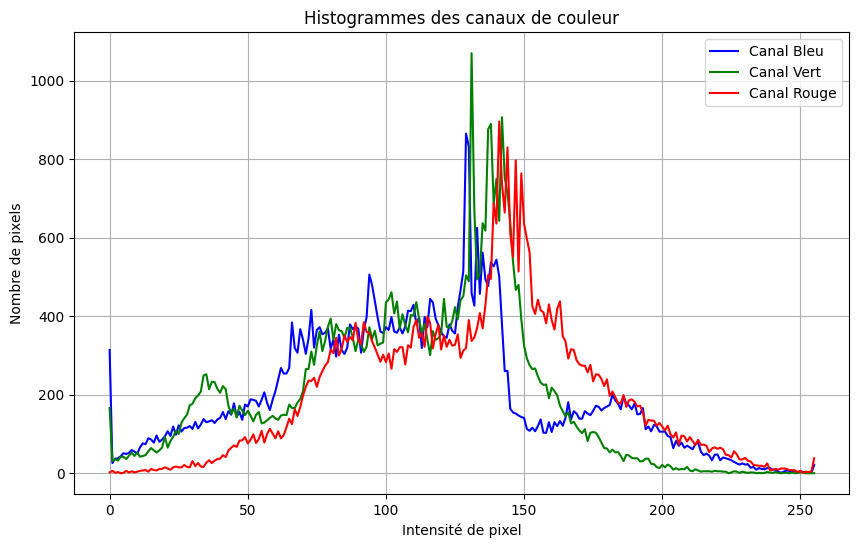

In [12]:
# Parcourir chaque pixel des canaux et remplir les histogrammes
for row in range(image_color.shape[0]):  # Parcours des lignes
     for col in range(image_color.shape[1]):  # Parcours des colonnes
            hist_blue[blue_channel[row, col]] += 1
            hist_green[green_channel[row, col]] += 1
            hist_red[red_channel[row, col]] += 1

    # Afficher les histogrammes
plt.figure(figsize=(10, 6))

    # Histogramme du canal bleu
plt.plot(hist_blue, color='blue', label='Canal Bleu')

    # Histogramme du canal vert
plt.plot(hist_green, color='green', label='Canal Vert')

    # Histogramme du canal rouge
plt.plot(hist_red, color='red', label='Canal Rouge')

    # Configuration du graphique
plt.title("Histogrammes des canaux de couleur")
plt.xlabel("Intensité de pixel")
plt.ylabel("Nombre de pixels")
plt.legend()
plt.grid(True)
plt.show()

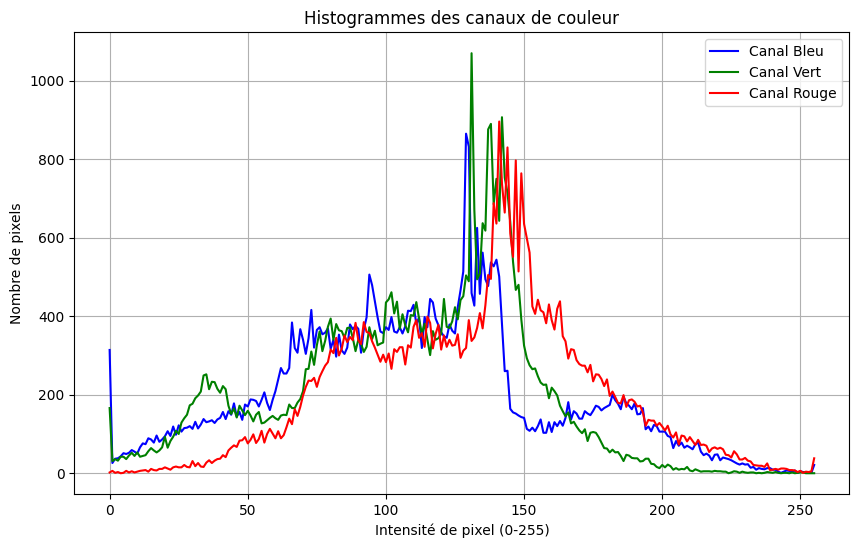

In [13]:
# Tracer les histogrammes
plt.figure(figsize=(10, 6))

    # Histogramme du canal bleu
plt.plot(hist_blue, color='blue', label='Canal Bleu')

    # Histogramme du canal vert
plt.plot(hist_green, color='green', label='Canal Vert')

    # Histogramme du canal rouge
plt.plot(hist_red, color='red', label='Canal Rouge')

    # Configuration du graphique
plt.title("Histogrammes des canaux de couleur")
plt.xlabel("Intensité de pixel (0-255)")
plt.ylabel("Nombre de pixels")
plt.legend()
plt.grid(True)
plt.show()

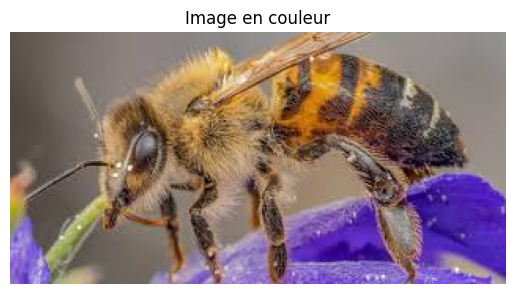

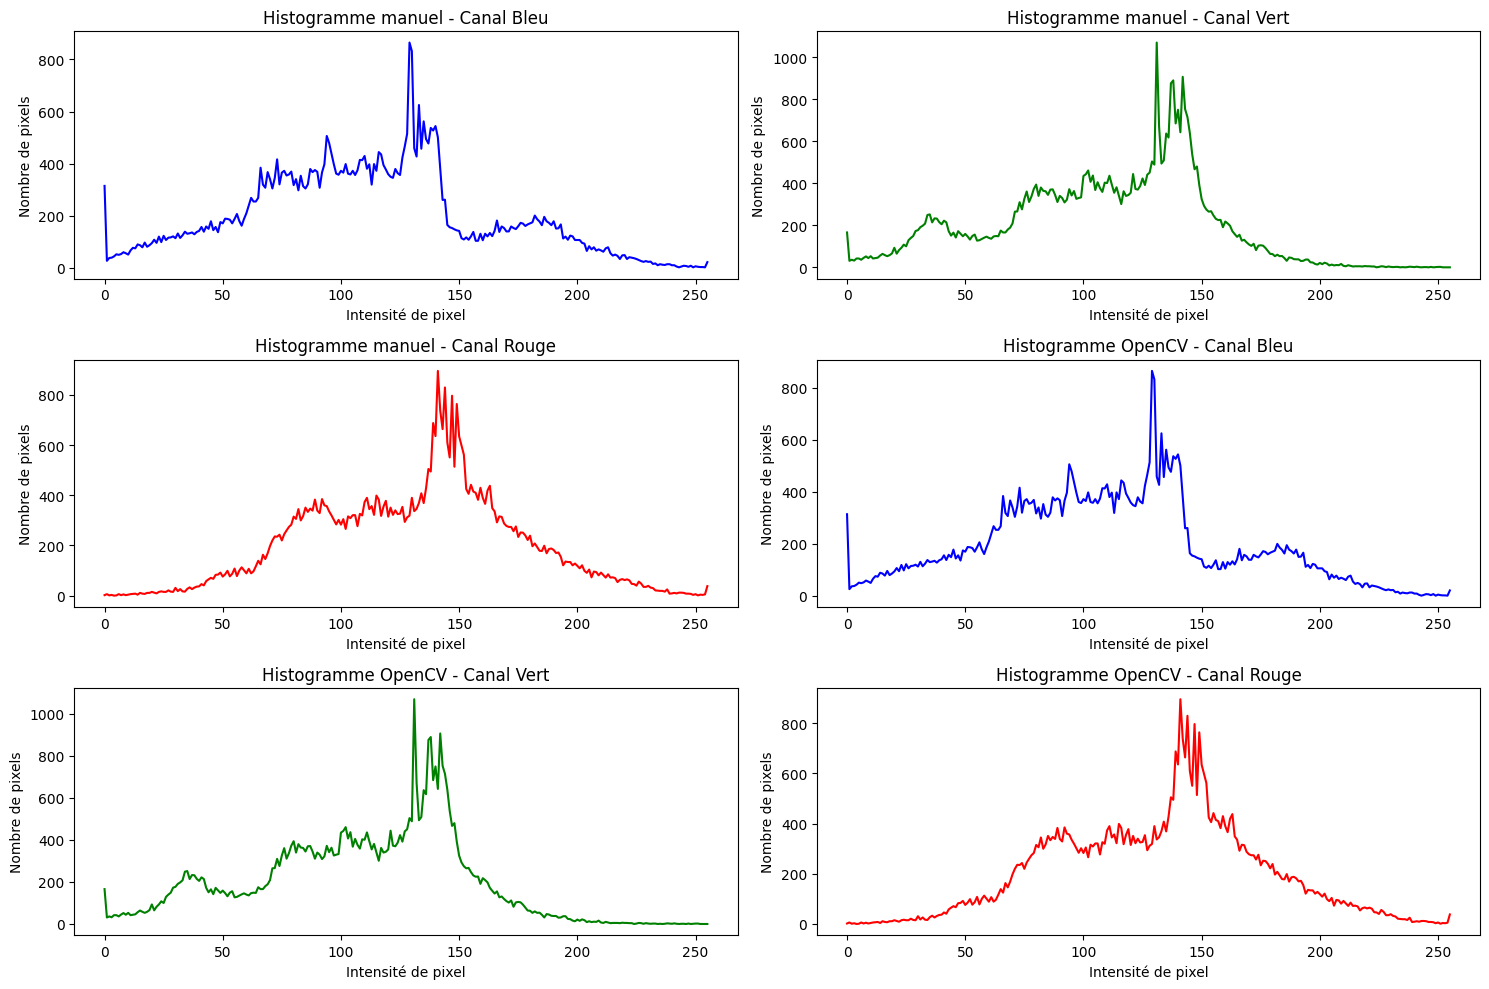

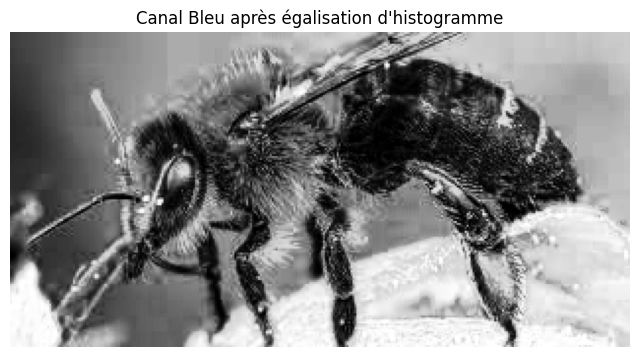

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Chargement de l'image
image_color = cv2.imread(r'C:\Users\mihna\OneDrive\Bureau\TR img\TP3 Ressources\bee1.tif')  # Modifier avec le chemin de votre image
if image_color is None:
    print("Erreur : L'image n'a pas pu être chargée.")
else:
    # Convertir l'image en RGB pour affichage (OpenCV charge en BGR par défaut)
    image_rgb = cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB)

    # Affichage de l'image originale
    plt.imshow(image_rgb)
    plt.title("Image en couleur")
    plt.axis('off')
    plt.show()

    # 2. Séparation des canaux
    blue_channel, green_channel, red_channel = cv2.split(image_color)

    # 3. Calcul manuel des histogrammes
    hist_blue = np.zeros(256, dtype=int)  # Histogramme pour le canal bleu
    hist_green = np.zeros(256, dtype=int)  # Histogramme pour le canal vert
    hist_red = np.zeros(256, dtype=int)  # Histogramme pour le canal rouge

    for row in range(image_color.shape[0]):  # Parcours des lignes
        for col in range(image_color.shape[1]):  # Parcours des colonnes
            hist_blue[blue_channel[row, col]] += 1
            hist_green[green_channel[row, col]] += 1
            hist_red[red_channel[row, col]] += 1

    # 4. Calcul des histogrammes avec OpenCV
    hist_blue_cv = cv2.calcHist([blue_channel], [0], None, [256], [0, 256])
    hist_green_cv = cv2.calcHist([green_channel], [0], None, [256], [0, 256])
    hist_red_cv = cv2.calcHist([red_channel], [0], None, [256], [0, 256])

    # Normalisation des histogrammes avec OpenCV
    hist_blue_norm = cv2.normalize(hist_blue_cv, None, 0, 255, cv2.NORM_MINMAX)
    hist_green_norm = cv2.normalize(hist_green_cv, None, 0, 255, cv2.NORM_MINMAX)
    hist_red_norm = cv2.normalize(hist_red_cv, None, 0, 255, cv2.NORM_MINMAX)

    # 5. Affichage des histogrammes
    plt.figure(figsize=(15, 10))

    # Histogrammes manuels
    plt.subplot(3, 2, 1)
    plt.plot(hist_blue, color='blue')
    plt.title("Histogramme manuel - Canal Bleu")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    plt.subplot(3, 2, 2)
    plt.plot(hist_green, color='green')
    plt.title("Histogramme manuel - Canal Vert")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    plt.subplot(3, 2, 3)
    plt.plot(hist_red, color='red')
    plt.title("Histogramme manuel - Canal Rouge")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    # Histogrammes avec OpenCV
    plt.subplot(3, 2, 4)
    plt.plot(hist_blue_cv, color='blue')
    plt.title("Histogramme OpenCV - Canal Bleu")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    plt.subplot(3, 2, 5)
    plt.plot(hist_green_cv, color='green')
    plt.title("Histogramme OpenCV - Canal Vert")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    plt.subplot(3, 2, 6)
    plt.plot(hist_red_cv, color='red')
    plt.title("Histogramme OpenCV - Canal Rouge")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")

    plt.tight_layout()
    plt.show()

    # 6. Égalisation d'histogramme pour le canal bleu
    equalized_blue = cv2.equalizeHist(blue_channel)

    # Affichage de l'image après égalisation
    plt.figure(figsize=(8, 8))
    plt.imshow(equalized_blue, cmap='gray')
    plt.title("Canal Bleu après égalisation d'histogramme")
    plt.axis('off')
    plt.show()


#### 3/ Appliquer des méthodes d’amélioration de la luminosité et de contraste

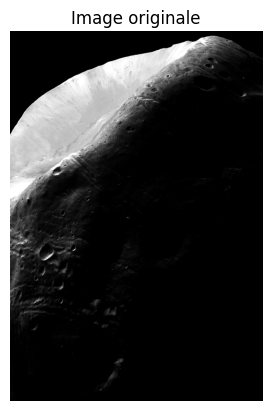

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Charger une image
image_path = r'C:\Users\mihna\OneDrive\Bureau\TR img\TP3 Ressources\Fig2.tif'  # Remplacez par votre chemin d'image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Chargement en niveaux de gris

# Affichage de l'image originale
plt.imshow(image, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.show()

    

In [18]:
# Calcul de la luminosité et des histogrammes
def calculate_histogram(image):
        hist = cv2.calcHist([image], [0], None, [256], [0, 256])
        hist_normalized = hist / hist.sum()
        hist_cumulative = hist_normalized.cumsum()
        return hist, hist_normalized, hist_cumulative

original_hist, original_hist_norm, original_hist_cum = calculate_histogram(image)

 


In [19]:
# Méthode 1 : Translation de l'histogramme (+50)
translated_image = cv2.add(image, 50)
translated_hist, _, _ = calculate_histogram(translated_image)



In [20]:


# Méthode 2 : Extension de l'histogramme
extended_image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
extended_hist, _, _ = calculate_histogram(extended_image)


In [21]:

# Méthode 3 : Expansion dynamique
a, b = np.min(image), np.max(image)  # Min et max de l'image
dynamic_image = ((image - a) / (b - a) * 255).astype(np.uint8)
dynamic_hist, _, _ = calculate_histogram(dynamic_image)

   

In [22]:
# Méthode 4 : Égalisation d'histogramme
equalized_image = cv2.equalizeHist(image)
equalized_hist, _, _ = calculate_histogram(equalized_image)

    

In [23]:
# Affichage des images transformées
images = [translated_image, extended_image, dynamic_image, equalized_image]
titles = ["Translation de l'histogramme (+50)", 
              "Extension de l'histogramme", 
              "Expansion dynamique", 
              "Égalisation d'histogramme"]

   

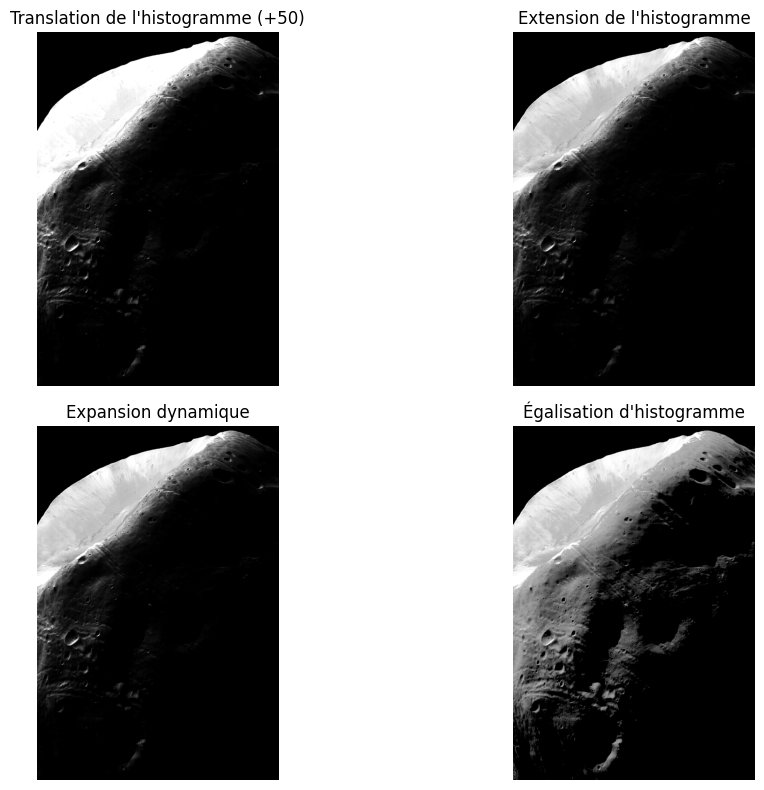

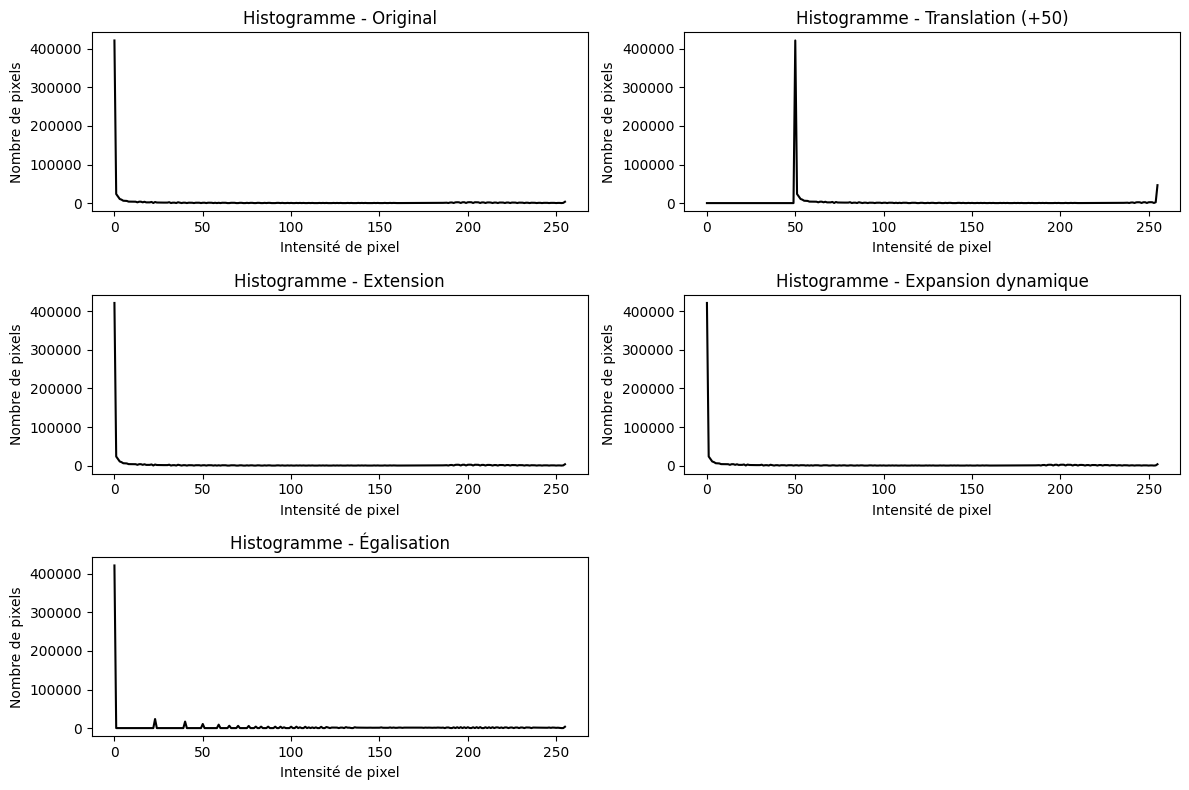

In [ ]:


# Affichage des images transformées
plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Affichage des histogrammes
plt.figure(figsize=(12, 8))
for i, (hist, title) in enumerate(zip(histograms, hist_titles)):
    plt.subplot(3, 2, i + 1)
    plt.plot(hist, color='black')
    plt.title(f"Histogramme - {title}")
    plt.xlabel("Intensité de pixel")
    plt.ylabel("Nombre de pixels")
plt.tight_layout()
plt.show()
